In [1]:
import pandas as pd

import os, sys
import matplotlib.pyplot as plt

sys.path.insert(0, "../../")

from progsnap2.spec.enums import MainTableColumns as Cols

In [43]:
all_dirs = {
    #'Ed_F21': 'sample_data/edwards/f21/analysis/',
    #'Ed_F19': 'sample_data/edwards/f19/analysis/',
    #'Ed_S19': 'sample_data/edwards/s19/analysis/',
    'CWO_S19': 'sample_data/codeworkout/s19/analysis/',
    'CWO_F19': 'sample_data/codeworkout/f19/analysis/',
    'CB_F24': 'sample_data/codebench/f24/analysis/',
    # 'Eng_S24': '../../../sample_data/CSC111/analysis/',
    'Fal_S21': 'sample_data/falcon/s21/analysis',
    'Fal_F21': 'sample_data/falcon/f21/analysis',
    'Fal_S22': 'sample_data/falcon/s22/analysis',
    'PCRS': 'sample_data/pcrs/analysis/',
}

In [44]:
overwrite = True

In [79]:
central_output_dir = 'sample_data/feature_importance/'
if overwrite:
    import shutil
    if not os.path.exists(central_output_dir):
        os.makedirs(central_output_dir)
    for name, dir in all_dirs.items():
        file_path = os.path.join(dir, 'subject_features.csv')
        if os.path.exists(file_path):
            # Copy the file to the central output directory
            new_name = f"{name}.csv"
            shutil.copy(file_path, os.path.join(central_output_dir, new_name))

In [80]:
def load_dataset(name):
    file_path = os.path.join(central_output_dir, f"{name}.csv")
    if not os.path.exists(file_path):
        print(f"Skipping missing file: {file_path}")
        return None
    data = pd.read_csv(file_path)
    # There's just one CS course with 18 students, so I don't think it's
    # worth treating as a separate prediction.
    if "X-ClassID" in data.columns:
        data = data[data["X-ClassID"] != 2607741091]
    if "final-grade" in data.columns:
        data.rename(columns={"final-grade": "Grade"}, inplace=True)
    if "FinalScore" in data.columns:
        data.rename(columns={"FinalScore": "Grade"}, inplace=True)
    if "exam2" in data.columns:
        data.rename(columns={"exam2": "Grade"}, inplace=True)
    if "X-Grade" in data.columns:
        data.rename(columns={"X-Grade": "Grade"}, inplace=True)
    if "Final" in data.columns:
        data.rename(columns={"Final": "Grade"}, inplace=True)
    if "h1_mean" in data.columns:
        data.rename(columns={"h1_mean": "hal_h1_mean"}, inplace=True)
    if "h2_mean" in data.columns:
        data.rename(columns={"h2_mean": "hal_h2_mean"}, inplace=True)
    if "n1_mean" in data.columns:
        data.rename(columns={"n1_mean": "hal_h1_mean"}, inplace=True)
    if "n2_mean" in data.columns:
        data.rename(columns={"n2_mean": "hal_h2_mean"}, inplace=True)
    if "Complexity_mean" in data.columns:
        data.rename(columns={"Complexity_mean": "avg_cc_mean"}, inplace=True)
    if "Comments_mean" in data.columns:
        data.rename(columns={"Comments_mean": "comments_mean"}, inplace=True)
    if "Lines_mean" in data.columns:
        data.rename(columns={"Lines_mean": "loc_mean"}, inplace=True)

    return data

In [81]:
from scipy.stats import pearsonr, spearmanr

def get_grade_correlations(data):
    skip_cols = ["X-ClassID", Cols.SubjectID, "Grade"]
    skip_cols = [col for col in skip_cols if col in data.columns]
    grades = data["Grade"]
    rows = []
    for col in data.columns:
        if col in skip_cols:
            continue
        corr, p_value = spearmanr(grades, data[col], nan_policy='omit')
        rows.append({"Feature": col, "Rho": corr, "p": p_value})
    return pd.DataFrame(rows)

In [82]:
row_counts = []
all_data = None
for name, dir in all_dirs.items():
    data = load_dataset(name)
    if data is None:
        continue
    # performance = get_basic_model_performance(data)
    row_counts.append({
        "Dataset": name,
        "Unique Students": data[Cols.SubjectID].nunique(),
        "Sections": data["X-ClassID"].nunique() if "X-ClassID" in data.columns else 1,
        "Rows": len(data),
        # **performance,
    })

    corrs = get_grade_correlations(data)
    corrs["Dataset"] = name
    corrs["Sample_size"] = len(data)
    if all_data is None:
        all_data = corrs
    else:
        all_data = pd.concat([all_data, corrs], ignore_index=True)
# all_data.sort_values(by="Feature", inplace=True)

# We want the sum instead of the mean for attempted (and to label it clearly)
# So this hack includes it among the other means
all_data["Feature"] = all_data["Feature"].str.replace("Attempted_sum", "Problems Attempted (Total)_mean", regex=False)
all_data["Feature"] = all_data["Feature"].str.replace("Attempted_mean", "Attempted mean", regex=False)


all_data = all_data[all_data["Feature"].str.endswith("_mean")]
all_data["Feature"] = all_data["Feature"].str.replace("_mean", "", regex=False)

ignore_features = [
    # Sort of arbitrary, not from the literature
    "ActiveTimeAfterCorrect",
    # Almost identical to Attempts (just includes after correct)
    "TotalAttempts",
    # These three were new ideas we added but don't add much on top of
    # the base metrics from which they were calculated.
    # Yes, that's a type on AtLeat
    "AtLeatMedianActiveTime",
    "AtLeatMedianMaxScore",
    "HadEffort",
]
all_data = all_data[~all_data["Feature"].isin(ignore_features)]

all_data["Feature"] = pd.Categorical(all_data["Feature"], categories=all_data["Feature"].unique(), ordered=True)
all_data

/var/folders/fh/j8r_pl3s1fl6hzg7s5qcxc3m0000gp/T/ipykernel_41299/2673640074.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_value = spearmanr(grades, data[col], nan_policy='omit')
/var/folders/fh/j8r_pl3s1fl6hzg7s5qcxc3m0000gp/T/ipykernel_41299/2673640074.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_value = spearmanr(grades, data[col], nan_policy='omit')
/var/folders/fh/j8r_pl3s1fl6hzg7s5qcxc3m0000gp/T/ipykernel_41299/2673640074.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_value = spearmanr(grades, data[col], nan_policy='omit')


,Feature,Rho,p,Dataset,Sample_size
0,ActiveTime,-0.120579,3.240542e-02,CWO_S19,315
1,PassiveTime,-0.062352,2.698908e-01,CWO_S19,315
2,TotalTime,-0.116745,3.837141e-02,CWO_S19,315
4,#Breaks,-0.101994,7.064893e-02,CWO_S19,315
5,StartTime,-0.145606,9.659726e-03,CWO_S19,315
...,...,...,...,...,...
513,loc,-0.018332,6.455274e-01,PCRS,632
515,sloc,-0.129852,1.068547e-03,PCRS,632
517,time,0.089389,2.462427e-02,PCRS,632
519,vocabulary,0.196000,6.840401e-07,PCRS,632


In [83]:
all_data.to_csv("all_data_test.csv", index=False)

In [84]:
print(all_data["Feature"].unique())

['ActiveTime', 'PassiveTime', 'TotalTime', '#Breaks', 'StartTime', ..., 'hal_volume', 'hal_difficulty', 'hal_effort', 'hal_time', 'hal_bugs']
Length: 52
Categories (52, object): ['ActiveTime' < 'PassiveTime' < 'TotalTime' < '#Breaks' ... 'hal_difficulty' < 'hal_effort' < 'hal_time' < 'hal_bugs']


In [ ]:
#get certain columns from all_data
features = ['Attempts', 'MaxScore', 'FirstCorrect', 'EverCorrect', 'Problems Attempted (Total)', 'StartTime', 'FirstCorrectTime',
 'ActiveTime', 'PassiveTime', 'TotalTime', 'avg_cc', 'loc', 'comments', 'hal_h1', 'hal_h2', 'ErrorQuotient', 'RepeatedErrorDensity',
 'FailedCompileCount']

all_data = all_data[all_data['Feature'].isin(features)]

In [ ]:
# Update some feature names for readability
all_data['Feature'] = all_data['Feature'].replace({'Problems Attempted (Total)': 'ProblemsStarted (Total)',
 'loc': 'Lines of Code (LoC)',
 'comments': 'Comments',
 'hal_h1': 'Distinct Operators (h1)',
 'hal_h2': 'Distinct Operands (h2)',
 'avg_cc': 'Cyclomatic Complexity (CC)'})

/var/folders/fh/j8r_pl3s1fl6hzg7s5qcxc3m0000gp/T/ipykernel_41299/2957800907.py:4: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  all_data['Feature'] = all_data['Feature'].replace({'Problems Attempted (Total)': 'ProblemsStarted (Total)',
/var/folders/fh/j8r_pl3s1fl6hzg7s5qcxc3m0000gp/T/ipykernel_41299/2957800907.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_data['Feature'] = all_data['Feature'].replace({'Problems Attempted (Total)': 'ProblemsStarted (Total)',


In [52]:
all_data.to_csv(os.path.join(central_output_dir, "spearman_correlations.csv"), index=False)

In [87]:
pd.DataFrame(row_counts).to_csv(os.path.join(central_output_dir, "row_counts.csv"), index=False)

In [88]:
pd.DataFrame(row_counts)

,Dataset,Unique Students,Sections,Rows
0,CWO_S19,315,1,315
1,CWO_F19,451,1,451
2,CB_F24,191,1,191
3,Fal_S21,481,1,481
4,Fal_F21,615,1,615
5,Fal_S22,442,1,442
6,PCRS,632,1,632


In [55]:
all_data.to_csv("all_data.csv", index=False)

In [89]:
print(all_data.columns)

Index(['Feature', 'Rho', 'p', 'Dataset', 'Sample_size'], dtype='object')


In [ ]:
#For eol
all_data_eol = pd.read_csv("sample_data/eol/all_data.csv")
print(all_data_eol["Feature"].unique())
print(all_data_eol.head())

['Attempts' 'MaxScore' 'ProblemsStarted (Total)' 'FirstCorrect'
 'EverCorrect' 'StartTime' 'FirstCorrectTime' 'ActiveTime' 'PassiveTime'
 'TotalTime' 'Cyclomatic Complexity (CC)' 'Lines of Code (LoC)' 'Comments'
 'Distinct Operators (h1)' 'Distinct Operands (h2)']
                   Feature       Rho             p      Dataset
0                 Attempts  0.049626  5.618121e-01  EOL_108_F22
1                 MaxScore  0.333377  6.063938e-05  EOL_108_F22
2  ProblemsStarted (Total)  0.401654  9.552102e-07  EOL_108_F22
3             FirstCorrect  0.095199  2.649444e-01  EOL_108_F22
4              EverCorrect  0.203882  1.606784e-02  EOL_108_F22


In [67]:
print(all_data_eol["Dataset"].unique())

['EOL_108_F22' 'EOL_106_F22' 'EOL_106_F23_noH' 'EOL_108_S24' 'EOL_106_S23'
 'EOL_106_S24' 'EOL_108_F23_noH' 'EOL_108_F23' 'EOL_108_S23'
 'EOL_106_F22_noH' 'EOL_106_F23']


In [68]:
all_data_eol_row_counts = pd.read_csv("sample_data/eol/all_data_row_counts.csv")
print(all_data_eol_row_counts.columns)
print(all_data_eol_row_counts["Dataset"].unique())

Index(['Dataset', 'Unique Students', 'Sections', 'Rows'], dtype='object')
['EOL_108_F22' 'EOL_106_F22' 'EOL_106_F23_noH' 'EOL_108_S24' 'EOL_106_S23'
 'EOL_106_S24' 'EOL_108_F23_noH' 'EOL_108_F23' 'EOL_108_S23'
 'EOL_106_F22_noH' 'EOL_106_F23']


In [69]:
print(all_data_eol["Feature"].unique())


['Attempts' 'MaxScore' 'ProblemsStarted (Total)' 'FirstCorrect'
 'EverCorrect' 'StartTime' 'FirstCorrectTime' 'ActiveTime' 'PassiveTime'
 'TotalTime' 'Cyclomatic Complexity (CC)' 'Lines of Code (LoC)' 'Comments'
 'Distinct Operators (h1)' 'Distinct Operands (h2)']


In [ ]:
#Add sample size to the data
all_data_eol.loc[all_data_eol["Dataset"] == "EOL_108_F22", "Sample_size"] = all_data_eol_row_counts.loc[all_data_eol_row_counts["Dataset"] == "EOL_108_F22", "Unique Students"].unique()[0]
all_data_eol.loc[all_data_eol["Dataset"] == "EOL_108_S23", "Sample_size"] = all_data_eol_row_counts.loc[all_data_eol_row_counts["Dataset"] == "EOL_108_S23", "Unique Students"].unique()[0]
all_data_eol.loc[all_data_eol["Dataset"] == "EOL_108_F23", "Sample_size"] = all_data_eol_row_counts.loc[all_data_eol_row_counts["Dataset"] == "EOL_108_F23", "Unique Students"].unique()[0]
all_data_eol.loc[all_data_eol["Dataset"] == "EOL_108_S24", "Sample_size"] = all_data_eol_row_counts.loc[all_data_eol_row_counts["Dataset"] == "EOL_108_S24", "Unique Students"].unique()[0]


all_data_eol.loc[all_data_eol["Dataset"] == "EOL_106_F22", "Sample_size"] = all_data_eol_row_counts.loc[all_data_eol_row_counts["Dataset"] == "EOL_106_F22", "Unique Students"].unique()[0]
all_data_eol.loc[all_data_eol["Dataset"] == "EOL_106_S23", "Sample_size"] = all_data_eol_row_counts.loc[all_data_eol_row_counts["Dataset"] == "EOL_106_S23", "Unique Students"].unique()[0]
all_data_eol.loc[all_data_eol["Dataset"] == "EOL_106_F23", "Sample_size"] = all_data_eol_row_counts.loc[all_data_eol_row_counts["Dataset"] == "EOL_106_F23", "Unique Students"].unique()[0]
all_data_eol.loc[all_data_eol["Dataset"] == "EOL_106_S24", "Sample_size"] = all_data_eol_row_counts.loc[all_data_eol_row_counts["Dataset"] == "EOL_106_S24", "Unique Students"].unique()[0]


In [71]:
selected_datasets = ['EOL_108_F22', 'EOL_108_S23', 'EOL_108_F23' , 'EOL_108_S24',
'EOL_106_F22', 'EOL_106_S23', 'EOL_106_F23' , 'EOL_106_S24']
all_data_eol = all_data_eol[all_data_eol['Dataset'].isin(selected_datasets)]
print(all_data_eol["Dataset"].unique())

['EOL_108_F22' 'EOL_106_F22' 'EOL_108_S24' 'EOL_106_S23' 'EOL_106_S24'
 'EOL_108_F23' 'EOL_108_S23' 'EOL_106_F23']


In [72]:
all_data_eol.to_csv("all_data_eol.csv")

In [ ]:
# aggregate all_data with all_data_eol
#concatenate all the semesters together
all_data = pd.concat([all_data, all_data_eol], ignore_index=True)

all_data.to_csv(os.path.join(central_output_dir, "spearman_correlations.csv"), index=False)
print(all_data.head())

            Feature       Rho         p  Dataset  Sample_size
0        ActiveTime -0.120579  0.032405  CWO_S19        315.0
1       PassiveTime -0.062352  0.269891  CWO_S19        315.0
2         TotalTime -0.116745  0.038371  CWO_S19        315.0
3         StartTime -0.145606  0.009660  CWO_S19        315.0
4  FirstCorrectTime  0.100518  0.074841  CWO_S19        315.0


In [ ]:
print(all_data["Dataset"].unique())
# write csv file
#all_data_sample.to_csv("all_data_sample.csv", index=False)


['CWO_S19' 'CWO_F19' 'CB_F24' 'Fal_S21' 'Fal_F21' 'Fal_S22' 'PCRS'
 'EOL_108_F22' 'EOL_106_F22' 'EOL_108_S24' 'EOL_106_S23' 'EOL_106_S24'
 'EOL_108_F23' 'EOL_108_S23' 'EOL_106_F23']


In [ ]:
print(all_data.columns)
# Sort features in a custom order
custom_order = ['StartTime', 'TotalTime', 'ActiveTime', 'FirstCorrectTime', 'PassiveTime',
'FirstCorrect', 'ProblemsStarted (Total)', 'Attempts', 'MaxScore', 'EverCorrect',
'Comments',  'Cyclomatic Complexity (CC)', 'Distinct Operands (h2)', 'Distinct Operators (h1)', 'Lines of Code (LoC)',
 'ErrorQuotient', 'FailedCompileCount', 'RepeatedErrorDensity']

# Convert the column to a Categorical type with your specified order
all_data['Feature'] = pd.Categorical(all_data['Feature'], categories=custom_order, ordered=True)

# Sort the DataFrame by that column
all_data = all_data.sort_values(by=['Dataset', 'Feature'])

all_data.to_csv(os.path.join(central_output_dir, "spearman_correlations_all_data.csv"), index=False)


Index(['Feature', 'Rho', 'p', 'Dataset', 'Sample_size'], dtype='object')


In [93]:
heat_map_values = all_data.pivot(index="Feature", columns="Dataset", values="Rho")
p_values = all_data.pivot(index="Feature", columns="Dataset", values="p")

import numpy as np

def significance_marker(p):
    if p < 0.001:
        return "***  "
    elif p < 0.01:
        return "**   "
    elif p < 0.05:
        return "*     "
    else:
        return " (ns)"

sig_marker_vec = np.vectorize(significance_marker)

markers = sig_marker_vec(p_values)
heat_map_annotations = heat_map_values.copy()
heat_map_annotations = heat_map_annotations.applymap(lambda x: f"{x:.2f}" if not pd.isna(x) else pd.NA) + markers


/var/folders/fh/j8r_pl3s1fl6hzg7s5qcxc3m0000gp/T/ipykernel_41299/3848115036.py:20: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  heat_map_annotations = heat_map_annotations.applymap(lambda x: f"{x:.2f}" if not pd.isna(x) else pd.NA) + markers


In [94]:
heat_map_annotations

Dataset,CB_F24,CWO_F19,CWO_S19,EOL_106_F22,EOL_106_F23,EOL_106_S23,EOL_106_S24,EOL_108_F22,EOL_108_F23,EOL_108_S23,EOL_108_S24,Fal_F21,Fal_S21,Fal_S22,PCRS
Feature,,,,,,,,,,,,,,,
StartTime,-0.28***,-0.23***,-0.15**,-0.20***,-0.31***,-0.26 (ns),-0.17 (ns),-0.39***,-0.37***,-0.38*,-0.51**,-0.32***,-0.39***,-0.40***,-0.34***
TotalTime,-0.20**,-0.28***,-0.12*,-0.44***,-0.54***,-0.13 (ns),-0.27**,-0.55***,-0.48***,-0.58***,-0.16 (ns),-0.38***,-0.47***,-0.54***,-0.47***
ActiveTime,-0.15*,-0.27***,-0.12*,-0.43***,-0.53***,-0.15 (ns),-0.26**,-0.56***,-0.49***,-0.55**,-0.12 (ns),-0.16***,-0.41***,-0.47***,-0.52***
FirstCorrectTime,0.75***,0.02 (ns),0.10 (ns),0.20***,0.04 (ns),0.36*,0.23*,0.19*,-0.06 (ns),-0.17 (ns),0.13 (ns),0.20***,0.31***,0.30***,-0.33***
PassiveTime,-0.21**,-0.22***,-0.06 (ns),-0.41***,-0.50***,-0.07 (ns),-0.25*,-0.49***,-0.45***,-0.64***,-0.19 (ns),-0.40***,-0.41***,-0.49***,-0.37***
FirstCorrect,0.36***,0.14**,0.05 (ns),0.22***,0.12 (ns),0.32*,0.37***,0.10 (ns),0.14 (ns),-0.22 (ns),0.50**,0.36***,0.32***,0.51***,0.49***
ProblemsStarted (Total),0.77***,0.03 (ns),0.06 (ns),0.48***,0.44***,0.47**,0.45***,0.40***,0.41***,0.29 (ns),0.29 (ns),0.39***,0.54***,0.45***,0.16***
Attempts,0.03 (ns),-0.27***,-0.10 (ns),0.07 (ns),-0.01 (ns),0.23 (ns),0.26*,0.05 (ns),-0.14 (ns),-0.14 (ns),0.12 (ns),-0.43***,-0.46***,-0.53***,-0.44***
MaxScore,0.75***,0.12*,0.15**,0.24***,0.27***,0.32*,0.29**,0.33***,0.09 (ns),0.04 (ns),0.43**,0.45***,0.50***,0.47***,0.05 (ns)


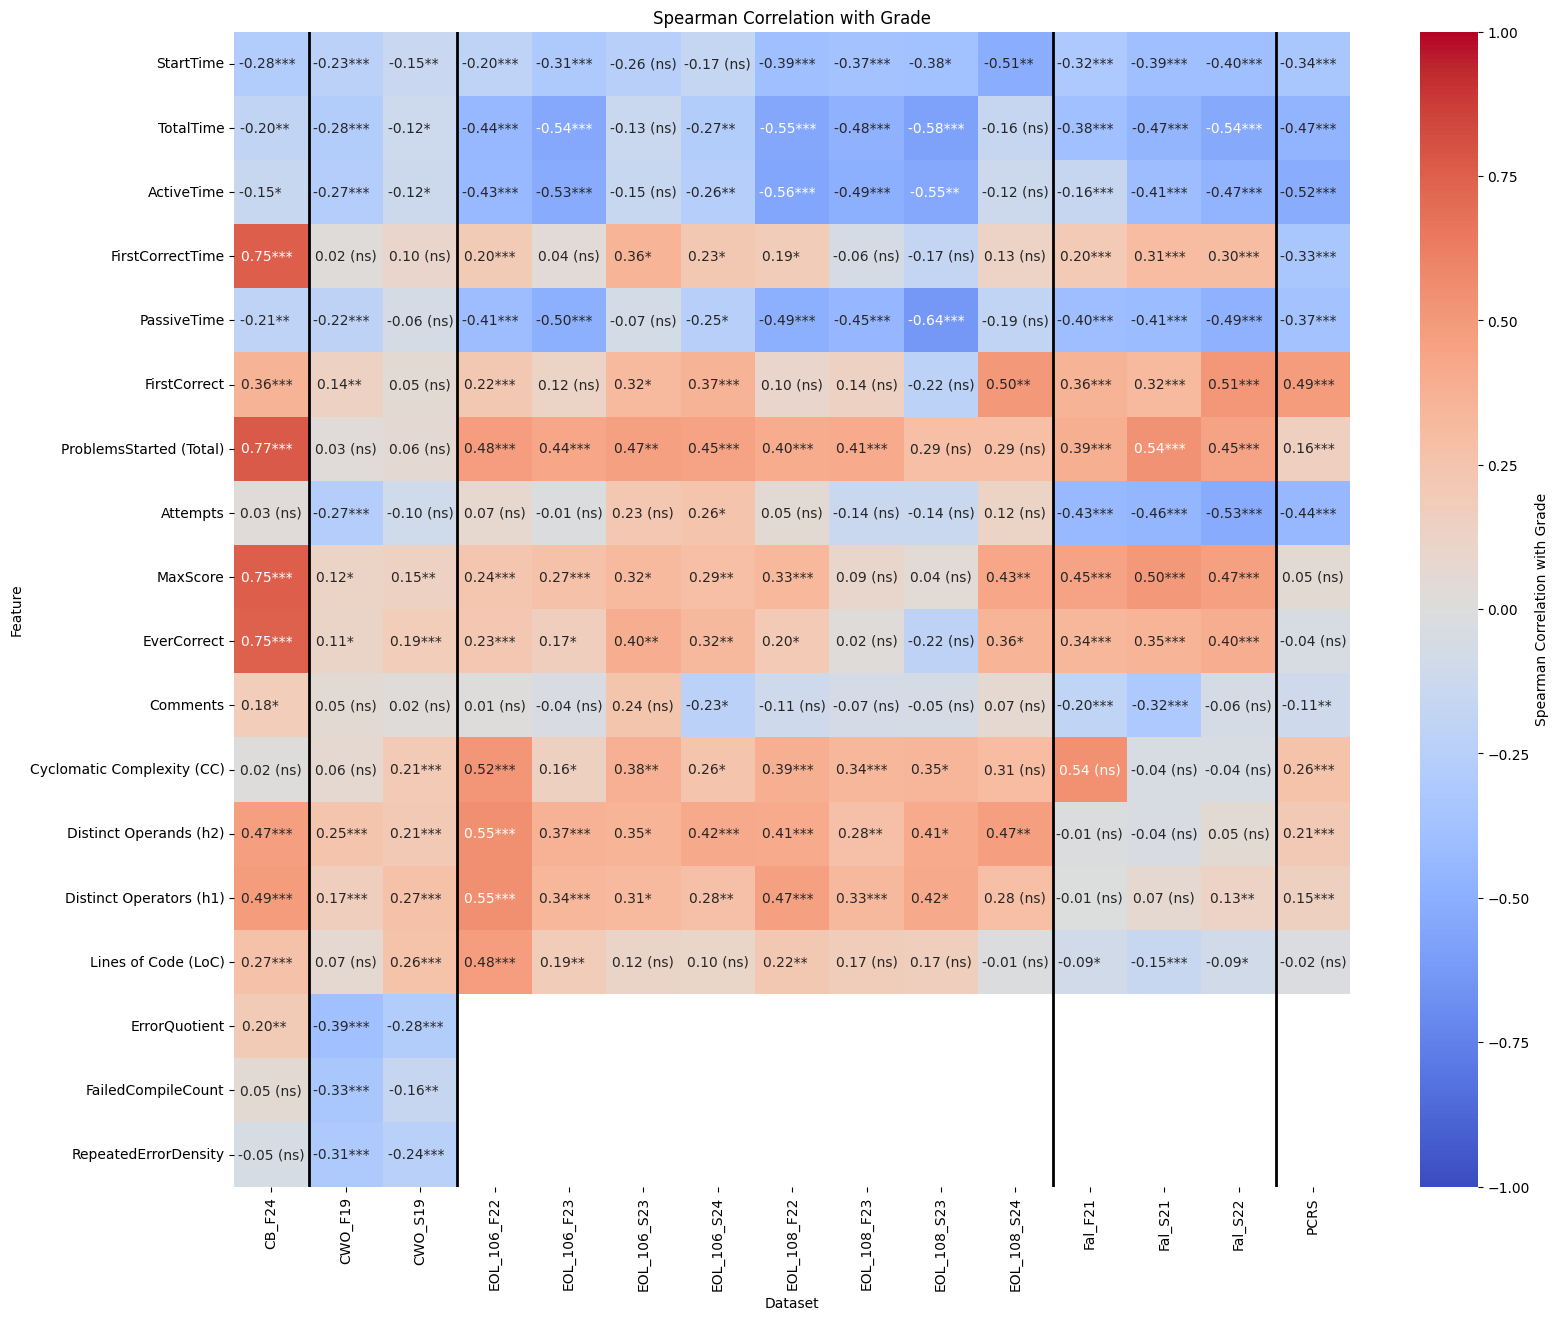

In [96]:
import seaborn as sns

plt.figure(figsize=(18, 15))
fig = sns.heatmap(data=heat_map_values,
    annot=heat_map_annotations,
    cmap="coolwarm",
    center=0,
    fmt="",
    vmin=-1, vmax=1,
    cbar_kws={"label": "Spearman Correlation with Grade"},
)
fig.set_title("Spearman Correlation with Grade")
fig.axvline(x=1, color='black', linewidth=2, linestyle='-')
fig.axvline(x=3, color='black', linewidth=2, linestyle='-')
fig.axvline(x=11, color='black', linewidth=2, linestyle='-')
fig.axvline(x=14, color='black', linewidth=2, linestyle='-')


# Save to PDF
plt.savefig(os.path.join(central_output_dir, "spearman_correlation_heatmap.pdf"), bbox_inches='tight')
plt.show()

In [ ]:
# Run ML Models
# Running XGBoost Classifier on Grade_Class

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

skip_cols = ["X-ClassID", Cols.SubjectID, "Grade", "Grade_Class"]
skip_cols = [col for col in skip_cols if col in data.columns]
X = data.drop(columns=skip_cols, axis=1)
y = data["Grade_Class"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2, # 20% test data
    random_state=42,
    stratify=y
)

model = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

In [ ]:
#Train the model
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

#Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: %.2f%%" % (accuracy * 100.0))
print(classification_report(y_test, y_pred))

In [ ]:
y_pred = model.predict(X_train)

accuracy = accuracy_score(y_train, y_pred)
print("Accuracy: %.2f%%" % (accuracy * 100.0))
print(classification_report(y_train, y_pred))

In [ ]:
#Running Cross Validation - 5 splits

from sklearn.model_selection import cross_val_score

#scores = cross_val_score(model, X, y, cv=5)
scores = cross_val_score(model, X, y, cv=5, scoring="f1_macro")

print("F1-Scores:", scores)
print("Mean F1-score:", scores.mean())
print("Std:", scores.std())

In [ ]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plot_importance(model)
plt.show()

In [ ]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, show=False)

In [ ]:
#Running XGBoost Regressor on Grade

skip_cols = ["X-ClassID", Cols.SubjectID, "Grade", "Grade_Class"]
skip_cols = [col for col in skip_cols if col in data.columns]
X = data.drop(columns=skip_cols, axis=1)
y = data["Grade"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
#grid search and random search can search for other parameters
# grid search is time consuming. We choose 5-6 parameters for each


model = XGBRegressor(
    n_estimators=300,
    max_depth=5,  # this parameter controls the complexity of the model (is it the complexity of features' interactions?)
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42
)

model.fit(X_train, y_train)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R²:", r2)

print("Train R2:", model.score(X_train, y_train))
print("Test R2:", model.score(X_test, y_test))

In [ ]:
import shap
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Summary Plot: PCRS - Predicting Final Grade")
#plt.tight_layout()
plt.show()

In [ ]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

In [ ]:
# Draw Scatter Plots

CWO_data_f19 = pd.read_csv("sample_data/codeworkout/f19/analysis/subject_features.csv")
CB_data = pd.read_csv("sample_data/codebench/f24/analysis/subject_features.csv")
PCRS_data = pd.read_csv("sample_data/pcrs/analysis/subject_features.csv")

data = CWO_data_f19
print(data.Attempted_sum.min())
print(data.Attempted_sum.max())
print(data.Attempted_sum.mean())

print(data.Grade.min())
print(data.Grade.max())
print(data.Grade.mean())


-7.210836869401755
0.2886206881954401
0.02781565234948794


Axes(0.125,0.11;0.775x0.77)


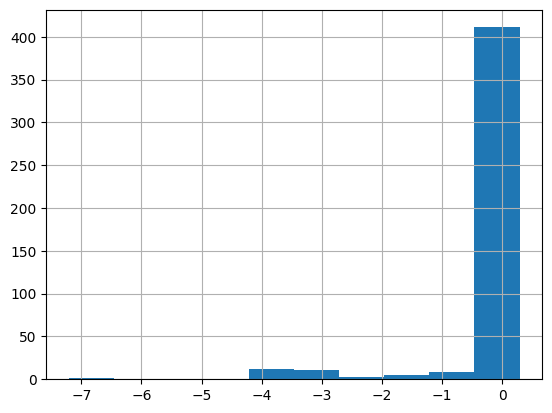

In [37]:
print(data.Attempted_sum.hist())

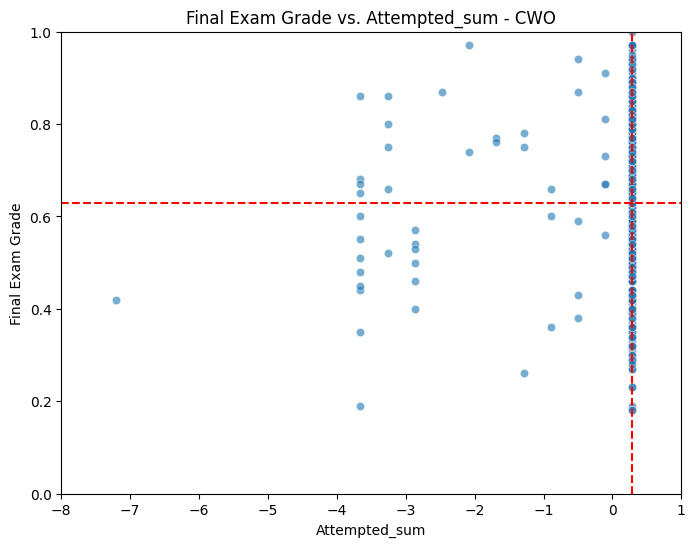

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

metric = "Attempted_sum"
grade = "Grade"
data_frame = CWO_data_f19

# Create the scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=data_frame, x=metric, y=grade, alpha=0.6)

# Add median or percentile lines to create the quadrants
plt.axvline(x=data[metric].quantile(0.50), color='red', linestyle='--')
plt.axhline(y=data[grade].quantile(0.50), color='red', linestyle='--')
plt.ylim(0, 1)
plt.xlim(-8, 1)

plt.xlabel(metric)
plt.ylabel('Final Exam Grade')
plt.title('Final Exam Grade vs. Attempted_sum - CWO')
plt.show()

<Axes: xlabel='Rho', ylabel='Feature'>

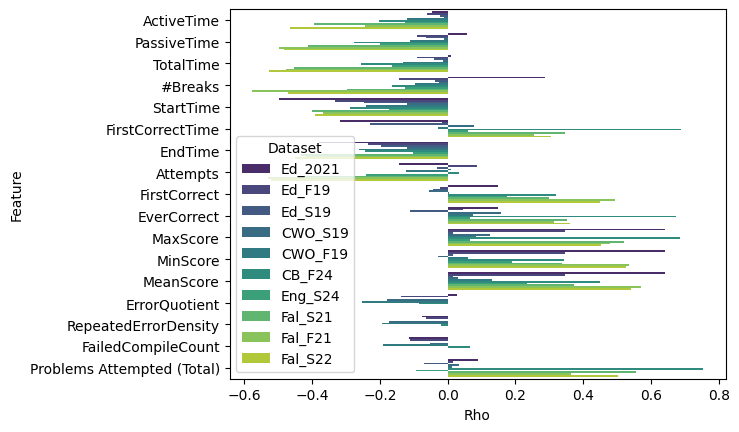

In [102]:
import seaborn as sns

sns.barplot(data=all_data,
    x="Rho",
    y="Feature",
    hue="Dataset",
    dodge=True,
    palette="viridis",
    orient="h",
)

In [22]:
skip_cols = ["X-ClassID", Cols.SubjectID]
skip_cols = [col for col in skip_cols if col in data.columns]

<Axes: >

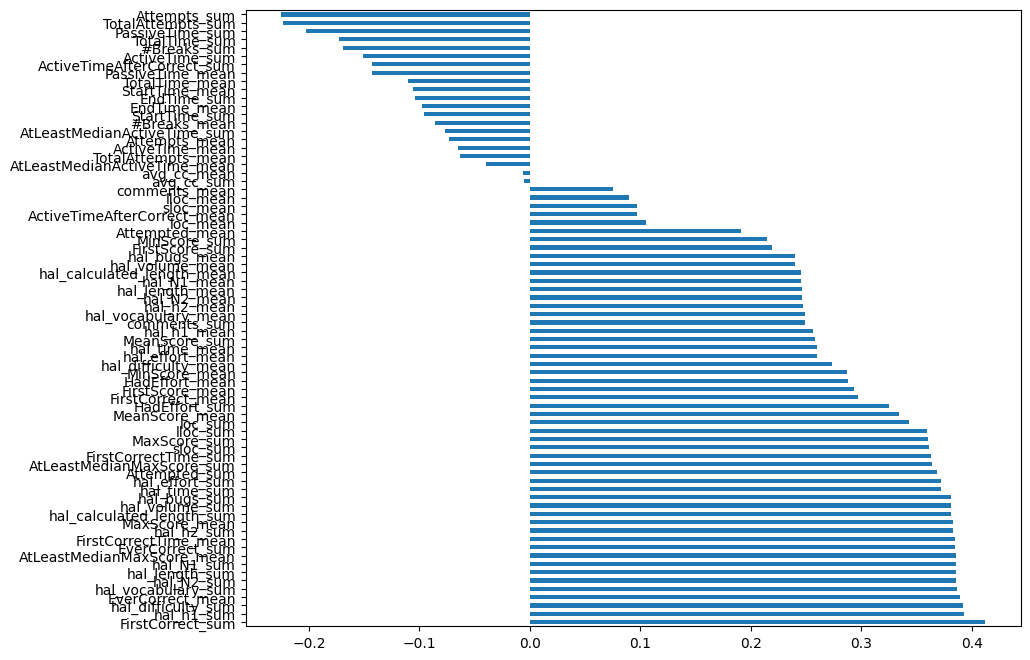

In [23]:
corrs = data.drop(columns=skip_cols).corr(method="spearman")["Grade"]
corrs = corrs[corrs != 1].sort_values(ascending=False)
corrs.plot(kind='barh', figsize=(10, 8))

In [ ]:
skip_cols = ["X-ClassID", Cols.SubjectID, "Grade"]
X = data.drop(columns=skip_cols + ['Grade'])
y = data['Grade']

In [64]:
# Drop columns with 0 variance
variance = X.var()
zero_variance_cols = variance[variance == 0].index
print (f"Dropping columns with zero variance: {zero_variance_cols.tolist()}")
X = X.drop(columns=zero_variance_cols)

Dropping columns with zero variance: []


In [65]:
linear_corr = X.corr()
# Find pairs that have correlation above 0.9
corr_pairs = linear_corr[linear_corr != 1].stack().reset_index()
corr_pairs.columns = ['Feature1', 'Feature2', 'Correlation']
high_corr_pairs = corr_pairs[abs(corr_pairs['Correlation']) > 0.9].reset_index(drop=True)
print("High correlation pairs:")
with pd.option_context('display.max_rows', None):
    print(high_corr_pairs)

High correlation pairs:
                 Feature1               Feature2  Correlation
0           MaxScore_mean       EverCorrect_mean     0.956211
1           MaxScore_mean  FirstCorrectTime_mean     0.999044
2        EverCorrect_mean          MaxScore_mean     0.956211
3        EverCorrect_mean  FirstCorrectTime_mean     0.955027
4   FirstCorrectTime_mean          MaxScore_mean     0.999044
5   FirstCorrectTime_mean       EverCorrect_mean     0.955027
6         ActiveTime_mean         TotalTime_mean     0.968588
7        PassiveTime_mean         TotalTime_mean     0.938709
8          TotalTime_mean        ActiveTime_mean     0.968588
9          TotalTime_mean       PassiveTime_mean     0.938709
10            hal_h1_mean            hal_h2_mean     0.912430
11            hal_h2_mean            hal_h1_mean     0.912430


<Axes: >

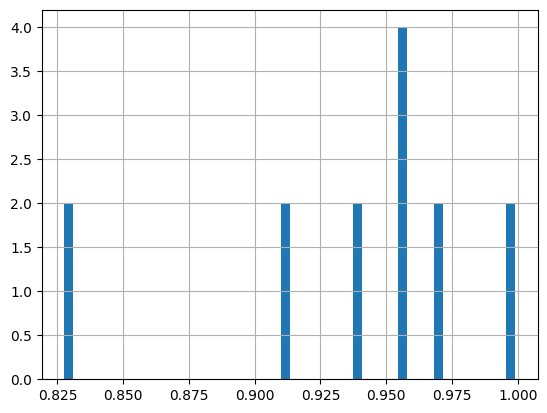

In [66]:
corr_pairs.Correlation[corr_pairs.Correlation > 0.7].hist(bins=50)

In [67]:
# For each highly correlated pair of features, drop the one with the lower
# correlation with the target variable
def drop_low_corr_feature(pair, X, y):
    feature1, feature2 = pair['Feature1'], pair['Feature2']
    corr1 = X[feature1].corr(y)
    corr2 = X[feature2].corr(y)
    if abs(corr1) > abs(corr2):
        return feature2
    else:
        return feature1

to_drop = high_corr_pairs.apply(drop_low_corr_feature, axis=1, X=X, y=y)
print(f"Dropping features with high correlation: {to_drop.tolist()}")
X_lean = X.drop(columns=to_drop)

Dropping features with high correlation: ['EverCorrect_mean', 'MaxScore_mean', 'EverCorrect_mean', 'EverCorrect_mean', 'MaxScore_mean', 'EverCorrect_mean', 'ActiveTime_mean', 'TotalTime_mean', 'ActiveTime_mean', 'TotalTime_mean', 'hal_h1_mean', 'hal_h1_mean']


In [68]:
X_lean.columns

Index(['Attempts_mean', 'FirstCorrect_mean', 'StartTime_mean',
       'FirstCorrectTime_mean', 'PassiveTime_mean', 'avg_cc_mean', 'loc_mean',
       'comments_mean', 'hal_h2_mean'],
      dtype='object')

In [ ]:
# Use the original data to peak at Grade
data.drop(columns=to_drop).drop(columns=skip_cols).corr(method='spearman')

,TotalTime_mean,ActiveTimeAfterCorrect_mean,#Breaks_mean,StartTime_mean,FirstCorrectTime_mean,Attempted_mean,MaxScore_mean,MinScore_mean,MeanScore_mean,ErrorQuotient_mean,...,HadEffort_mean,ActiveTimeAfterCorrect_sum,EndTime_sum,FirstCorrect_sum,EverCorrect_sum,Attempted_sum,ErrorQuotient_sum,RepeatedErrorDensity_sum,FailedCompileCount_sum,Grade
TotalTime_mean,1.000000,NaN,0.727732,-0.347213,0.102439,0.156797,0.232299,0.232299,0.232299,-0.108490,...,0.573165,NaN,0.188502,0.271901,0.271901,0.284463,-0.076804,-0.087355,0.558014,0.010105
ActiveTimeAfterCorrect_mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
#Breaks_mean,0.727732,NaN,1.000000,-0.602901,-0.022562,-0.017267,0.342272,0.342272,0.342272,-0.076697,...,0.384178,NaN,0.014896,0.254754,0.254754,0.225758,-0.042272,-0.039511,0.368744,0.287643
StartTime_mean,-0.347213,NaN,-0.602901,1.000000,0.322997,0.149331,-0.461807,-0.461807,-0.461807,0.150924,...,-0.377014,NaN,0.513763,-0.206786,-0.206786,-0.055678,0.142060,0.063432,-0.088153,-0.496167
FirstCorrectTime_mean,0.102439,NaN,-0.022562,0.322997,1.000000,0.373327,-0.007674,-0.007674,-0.007674,0.238813,...,-0.090333,NaN,0.434146,0.153989,0.153989,-0.167033,0.267525,0.269678,0.144599,-0.311324
Attempted_mean,0.156797,NaN,-0.017267,0.149331,0.373327,1.000000,0.317193,0.317193,0.317193,-0.091470,...,0.257389,NaN,0.099398,0.412479,0.412479,0.501652,-0.097909,-0.145638,0.120865,0.088198
MaxScore_mean,0.232299,NaN,0.342272,-0.461807,-0.007674,0.317193,1.000000,1.000000,1.000000,-0.208914,...,0.677806,NaN,-0.279037,0.487556,0.487556,0.287801,-0.229082,-0.218798,0.016393,0.627834
MinScore_mean,0.232299,NaN,0.342272,-0.461807,-0.007674,0.317193,1.000000,1.000000,1.000000,-0.208914,...,0.677806,NaN,-0.279037,0.487556,0.487556,0.287801,-0.229082,-0.218798,0.016393,0.627834
MeanScore_mean,0.232299,NaN,0.342272,-0.461807,-0.007674,0.317193,1.000000,1.000000,1.000000,-0.208914,...,0.677806,NaN,-0.279037,0.487556,0.487556,0.287801,-0.229082,-0.218798,0.016393,0.627834
ErrorQuotient_mean,-0.108490,NaN,-0.076697,0.150924,0.238813,-0.091470,-0.208914,-0.208914,-0.208914,1.000000,...,-0.207970,NaN,-0.188431,-0.400091,-0.400091,-0.595279,0.993228,0.818333,0.259974,0.028102


In [30]:
from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_lean, y, test_size=0.25, random_state=42)

In [16]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    # 'n_estimators': [50, 100, 200, 350, 500],
    'n_estimators': [10, 20, 50, 100, 200],
    'max_depth': [1, 5, 10, 20, 30],
}

rf = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='neg_mean_absolute_error', return_train_score=True)

grid_search.fit(X_train, y_train)
print("Best parameters found: ", grid_search.best_params_)

Best parameters found:  {'max_depth': 5, 'n_estimators': 200}


In [17]:
pd.DataFrame(grid_search.cv_results_)[["mean_train_score", "mean_test_score", "std_test_score", "params"]]

,mean_train_score,mean_test_score,std_test_score,params
0,-6.841851,-11.540605,4.224044,"{'max_depth': 1, 'n_estimators': 10}"
1,-6.599704,-11.298883,3.847665,"{'max_depth': 1, 'n_estimators': 20}"
2,-6.494332,-11.312684,3.730622,"{'max_depth': 1, 'n_estimators': 50}"
3,-6.552314,-11.352373,3.727654,"{'max_depth': 1, 'n_estimators': 100}"
4,-6.427500,-11.133114,3.815339,"{'max_depth': 1, 'n_estimators': 200}"
5,-4.146189,-11.231377,4.107577,"{'max_depth': 5, 'n_estimators': 10}"
6,-3.577173,-10.908503,4.044078,"{'max_depth': 5, 'n_estimators': 20}"
7,-3.497982,-10.940448,3.774897,"{'max_depth': 5, 'n_estimators': 50}"
8,-3.710473,-10.837427,3.660293,"{'max_depth': 5, 'n_estimators': 100}"
9,-3.753827,-10.696553,3.730171,"{'max_depth': 5, 'n_estimators': 200}"


<Axes: xlabel='mean_train_score', ylabel='mean_test_score'>

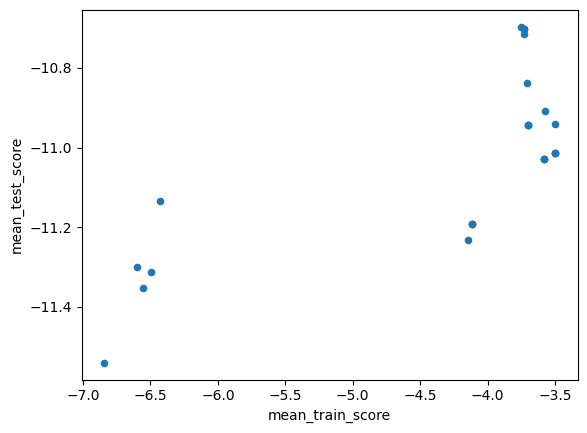

In [18]:
pd.DataFrame(grid_search.cv_results_).plot.scatter("mean_train_score", "mean_test_score")

In [19]:
from sklearn.linear_model import LassoCV

lasso = LassoCV(cv=5, random_state=42)
lasso.fit(X_train, y_train)

# Create a table of each feature and its coefficient
lasso_coef = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lasso.coef_,
    'Abs_Coefficient': abs(lasso.coef_)
})
lasso_coef.sort_values(by='Abs_Coefficient', ascending=False)


,Feature,Coefficient,Abs_Coefficient
11,HadEffort_mean,7.966799e+00,7.966799e+00
5,MaxScore_mean,1.352861e+00,1.352861e+00
4,Attempted_mean,-1.053030e+00,1.053030e+00
10,AtLeatMedianMaxScore_mean,5.905328e-02,5.905328e-02
6,MinScore_mean,1.072991e-14,1.072991e-14
0,TotalTime_mean,0.000000e+00,0.000000e+00
1,#Breaks_mean,0.000000e+00,0.000000e+00
2,StartTime_mean,-0.000000e+00,0.000000e+00
3,FirstCorrectTime_mean,-0.000000e+00,0.000000e+00
8,ErrorQuotient_mean,0.000000e+00,0.000000e+00


In [20]:
from sklearn.ensemble import GradientBoostingRegressor
gb = GradientBoostingRegressor(random_state=42)
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
}
gb_grid_search = GridSearchCV(gb, param_grid, cv=5, scoring='neg_mean_absolute_error')
gb_grid_search.fit(X_train, y_train)

,estimator,GradientBoost...ndom_state=42)
,param_grid,"{'learning_rate': [0.01, 0.1, ...], 'max_depth': [3, 5, ...], 'n_estimators': [50, 100, ...]}"
,scoring,'neg_mean_absolute_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'squared_error'


In [21]:
pd.DataFrame(gb_grid_search.cv_results_)[["mean_test_score", "std_test_score", "params"]]

,mean_test_score,std_test_score,params
0,-9.740522,3.692831,"{'learning_rate': 0.01, 'max_depth': 3, 'n_est..."
1,-9.830861,3.655241,"{'learning_rate': 0.01, 'max_depth': 3, 'n_est..."
2,-9.768446,3.620371,"{'learning_rate': 0.01, 'max_depth': 3, 'n_est..."
3,-9.828029,3.514749,"{'learning_rate': 0.01, 'max_depth': 5, 'n_est..."
4,-9.723163,3.619472,"{'learning_rate': 0.01, 'max_depth': 5, 'n_est..."
5,-9.910764,3.775390,"{'learning_rate': 0.01, 'max_depth': 5, 'n_est..."
6,-9.844616,3.658429,"{'learning_rate': 0.01, 'max_depth': 7, 'n_est..."
7,-9.942036,3.587417,"{'learning_rate': 0.01, 'max_depth': 7, 'n_est..."
8,-10.314312,3.569140,"{'learning_rate': 0.01, 'max_depth': 7, 'n_est..."
9,-10.346695,3.520657,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti..."


In [22]:
from sklearn.metrics import mean_absolute_error, r2_score

print(mean_absolute_error(y_test, grid_search.predict(X_test)))
print(r2_score(y_test, grid_search.predict(X_test)))

12.52440738577527
-6.830668869258588


In [23]:
print(mean_absolute_error(y_test, lasso.predict(X_test)))
print(r2_score(y_test, lasso.predict(X_test)))

10.900435199452081
-4.1519921563671796


In [24]:
print(mean_absolute_error(y_test, gb_grid_search.predict(X_test)))
print(r2_score(y_test, gb_grid_search.predict(X_test)))

9.511603778705144
-5.777160953194817


In [26]:
from sklearn.linear_model import LinearRegression

linear_reg = LinearRegression()
linear_reg.fit(X_train[['EverCorrect_sum']], y_train)

ever_correct_baseline = linear_reg.predict(X_test[['EverCorrect_sum']])
print(mean_absolute_error(y_test, ever_correct_baseline))
print(r2_score(y_test, ever_correct_baseline))

7.511927710843387
-1.1477574057649993


In [25]:
from sklearn.dummy import DummyRegressor

dummy_regressor = DummyRegressor(strategy='mean')
dummy_regressor.fit(X_train, y_train)

print(mean_absolute_error(y_test, dummy_regressor.predict(X_test)))
print(r2_score(y_test, dummy_regressor.predict(X_test)))

5.809545454545468
-0.23218936399607681


<Axes: >

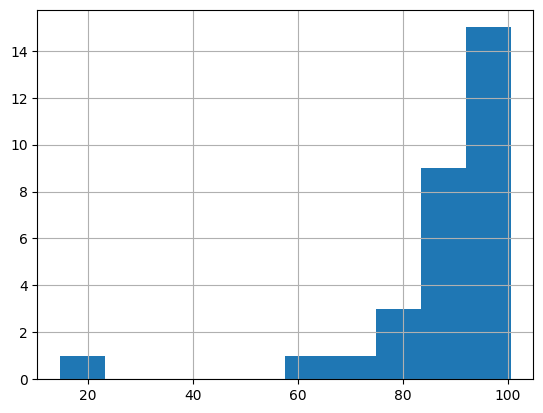

In [27]:
y_train.hist()

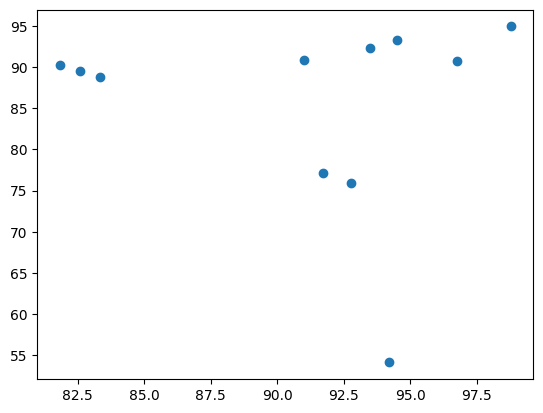

In [28]:
plt.scatter(y_test, gb_grid_search.predict(X_test))

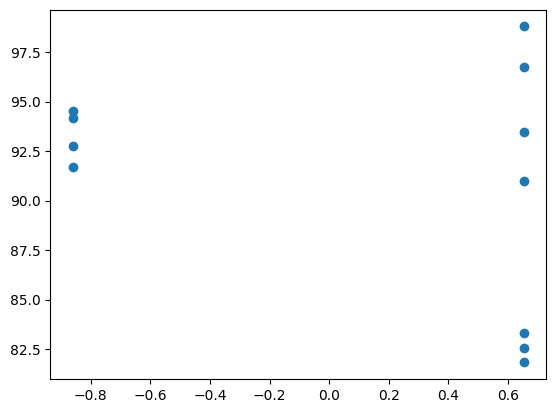

In [29]:
plt.scatter(X_test['EverCorrect_sum'], y_test)